# 📈 Uber Technologies (UBER) — Stock Price & Volatility Analysis

**Data Period:** 2019 - 2025

---

## 🧭 Project Purpose

Uber Technologies went public in May 2019 at $45 — and promptly fell. Since then it
has survived a global pandemic, a ride-share collapse, a freight recession, and a
macro rate-shock. This notebook uses that full history to answer one central
question:

> **Can we model and forecast how *risky* Uber stock is likely to be on any given
> future trading day — and how did that risk evolve over time?**

We are trying to quantify and forecast the *magnitude* of daily price swings — which matters for:
- Options traders pricing contracts
- Portfolio managers sizing positions
- Risk managers computing dynamic Value-at-Risk

---

## 🗂️ Notebook Structure

| # | Section | What It Does |
|---|---|---|
| 1 | Setup | Load data, run pipeline, inspect the DataFrame |
| 2 | Price History | Visualise the full price series and key events |
| 3 | Return Distributions | Show fat tails, non-normality, and the case for Student-t |
| 4 | Rolling Volatility | Demonstrate time-varying risk with 21D and 63D windows |
| 5 | Risk Metrics | Annualised return, Sharpe, VaR, CVaR, Max Drawdown |
| 6 | Statistical Tests | ADF (stationarity), Jarque-Bera (normality), ARCH (volatility clustering) |
| 7 | Why GARCH? | The statistical motivation for time-varying volatility models |
| 8 | GARCH(1,1) Model | Parameters, equations, and interpretation |
| 9 | In-Sample Fit | Did the model capture the volatility clusters? |
| 10 | OOS Evaluation | Forecasting performance on the held-out 20% test set |
| 11 | Future Forecast | 5-day-ahead annualized volatility |
| 12 | Model Validation | Residual diagnostics — did GARCH remove the ARCH effects? |
| 13 | Drawdown | Maximum underwater periods |
| 14 | Summary | Key findings and real-world applications |

---

## 🔑 Key Concept: Why Log-Returns?

Raw **prices** are non-stationary — they drift upward over time and cannot be
compared across different starting levels. **Log-returns** solve both problems:

- They are approximately stationary (mean-reverting around zero)
- They are additive over time (daily log-returns sum to the total log-return)
- They are symmetric around zero (a +10% and -10% move are equal in magnitude)
- They feed directly into GARCH and other time-series volatility models


In [1]:
# ── Standard library ──────────────────────────────────────────────────────
import sys, os, warnings
warnings.filterwarnings("ignore")

# ── Add src/ to path so imports work from the notebooks/ directory ─────────
sys.path.insert(0, os.path.join("..", "src"))

# ── Scientific stack ──────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.dates   as mdates
import seaborn            as sns

# ── Display helpers ───────────────────────────────────────────────────────
from IPython.display import display, Image, HTML

# ── Project pipeline ──────────────────────────────────────────────────────
from uber_stock.pipeline import run_full_analysis

# ── Global plot style ─────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})

df, metrics, garch_result = run_full_analysis()

print("✅  Pipeline complete.")
print(f"    Rows        : {len(df):,}  trading days")
print(f"    Date range  : {df.index.min().date()}  →  {df.index.max().date()}")
print(f"    Columns     : {list(df.columns)}")

  Data loaded: 1,444 actual trading days (2019-01-07 → 2025-10-01)
  GARCH split  →  train: 1154 days  |  test: 289 days
  Train period :  2019-01-08  →  2023-12-09
  Test  period :  2023-12-10   →  2025-10-01
  Return std (pct/day): 13.3820  ← should be 0.5–5.0
✅  Pipeline complete.
    Rows        : 1,444  trading days
    Date range  : 2019-01-07  →  2025-10-01
    Columns     : ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'price', 'simple_return', 'log_return', 'log_return_pct', 'log_volume', 'volume_log_change', 'weekday', 'year', 'month', 'quarter', 'vol_21d', 'vol_63d', 'cum_return', 'rolling_peak', 'drawdown', 'ret_lag1', 'ret_lag2', 'ret_lag5']


In [2]:
print("── Head (first 5 rows) ───────────────────────────────────────────────")
display(df.head())

print("\n── Tail (last 5 rows) ────────────────────────────────────────────────")
display(df.tail())

print("\n── Descriptive statistics for key columns ───────────────────────────")
key_cols = ["price", "log_return", "log_return_pct", "vol_21d", "vol_63d",
            "simple_return", "cum_return", "drawdown"]
display(df[key_cols].describe().round(6))

── Head (first 5 rows) ───────────────────────────────────────────────


,Adj Close,Close,High,Low,Open,Volume,price,simple_return,log_return,log_return_pct,...,month,quarter,vol_21d,vol_63d,cum_return,rolling_peak,drawdown,ret_lag1,ret_lag2,ret_lag5
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-07,44.270000,44.270000,47.040001,44.060001,46.980000,17660500,44.270000,NaN,NaN,NaN,...,1,1,NaN,NaN,1.000000,1.0,0.000000,NaN,NaN,NaN
2019-01-08,41.310001,41.310001,42.535999,41.000000,42.139999,7349700,41.310001,-0.066862,-0.069203,-6.920262,...,1,1,NaN,NaN,0.933138,1.0,-0.066862,NaN,NaN,NaN
2019-01-10,29.150000,29.150000,30.510000,28.650000,30.370001,13380200,29.150000,-0.294360,-0.348650,-34.864973,...,1,1,NaN,NaN,0.658459,1.0,-0.341541,-0.069203,NaN,NaN
2019-01-11,31.370001,31.370001,31.700001,30.740999,31.450001,10434300,31.370001,0.076158,0.073397,7.339715,...,1,1,NaN,NaN,0.708606,1.0,-0.291394,-0.348650,-0.069203,NaN
2019-02-07,44.000000,44.000000,44.680000,43.750000,44.549999,11881300,44.000000,0.402614,0.338338,33.833758,...,2,1,NaN,NaN,0.993901,1.0,-0.006099,0.073397,-0.348650,NaN



── Tail (last 5 rows) ────────────────────────────────────────────────


,Adj Close,Close,High,Low,Open,Volume,price,simple_return,log_return,log_return_pct,...,month,quarter,vol_21d,vol_63d,cum_return,rolling_peak,drawdown,ret_lag1,ret_lag2,ret_lag5
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-02,64.480003,64.480003,66.750000,63.500000,66.500000,74772959,64.480003,-0.075556,-0.078562,-7.856227,...,5,2,0.536466,1.112922,1.456517,1.950305,-0.253185,0.035906,0.040952,0.003897
2025-06-01,66.309998,66.309998,67.349998,66.040001,66.970001,32980700,66.309998,0.028381,0.027986,2.798553,...,6,2,0.542554,1.097948,1.497854,1.950305,-0.231990,-0.078562,0.035906,-0.056622
2025-07-01,66.150002,66.150002,68.839996,65.949997,68.489998,35347800,66.150002,-0.002413,-0.002416,-0.241576,...,7,3,0.541481,1.067944,1.494240,1.950305,-0.233843,0.027986,-0.078562,0.022230
2025-08-01,64.910004,64.910004,66.680000,64.120003,66.400002,24523300,64.910004,-0.018745,-0.018923,-1.892316,...,8,3,0.459090,0.989227,1.466230,1.950305,-0.248205,-0.002416,0.027986,0.040952
2025-10-01,65.970001,65.970001,66.599998,63.959999,64.500000,30728800,65.970001,0.016330,0.016198,1.619836,...,10,4,0.460208,0.989531,1.490174,1.950305,-0.235928,-0.018923,-0.002416,0.035906



── Descriptive statistics for key columns ───────────────────────────


,price,log_return,log_return_pct,vol_21d,vol_63d,simple_return,cum_return,drawdown
count,1444.000000,1443.000000,1443.000000,1423.000000,1381.000000,1443.000000,1444.000000,1444.000000
mean,44.465374,0.000276,0.027643,2.054770,2.071434,0.009255,1.004413,-0.300285
std,15.594262,0.133820,13.381974,0.672632,0.524513,0.137622,0.352253,0.175169
min,14.820000,-0.843244,-84.324414,0.349521,0.936084,-0.569688,0.334764,-0.720851
25%,31.930000,-0.029647,-2.964703,1.611098,1.699248,-0.029212,0.721256,-0.433194
50%,41.355001,-0.001302,-0.130244,1.986078,2.096133,-0.001302,0.934154,-0.296929
75%,54.719999,0.031898,3.189759,2.484822,2.400787,0.032412,1.236051,-0.151720
max,86.339996,0.707463,70.746261,4.486491,3.507182,1.028837,1.950305,0.000000


---

## 1️⃣  Price History

The chart below shows Uber's **adjusted close price** from its NYSE debut in May 2019
through the present. Key macro events have left clear marks on the price series:

| Period | Event | Impact on UBER |
|---|---|---|
| May 2019 | IPO at ~$45 | Immediately fell below IPO price |
| Feb–Mar 2020 | COVID-19 crash | Price halved in weeks (~$45 → ~$14) |
| May 2020 | Post-lockdown re-opening | Sharp recovery rally |
| Nov 2021 | Peak valuation | UBER reached ~$63 |
| 2022 | Fed rate hikes + recession fears | Fell back to ~$20 |
| 2023–2024 | Profitable operations confirmed | Steady recovery to $60–$80 |

**Observation:** The price series is clearly **non-stationary** — it has a trend and
the variance is not constant across time. This is why we never model raw prices
with GARCH. We must first convert to log-returns.

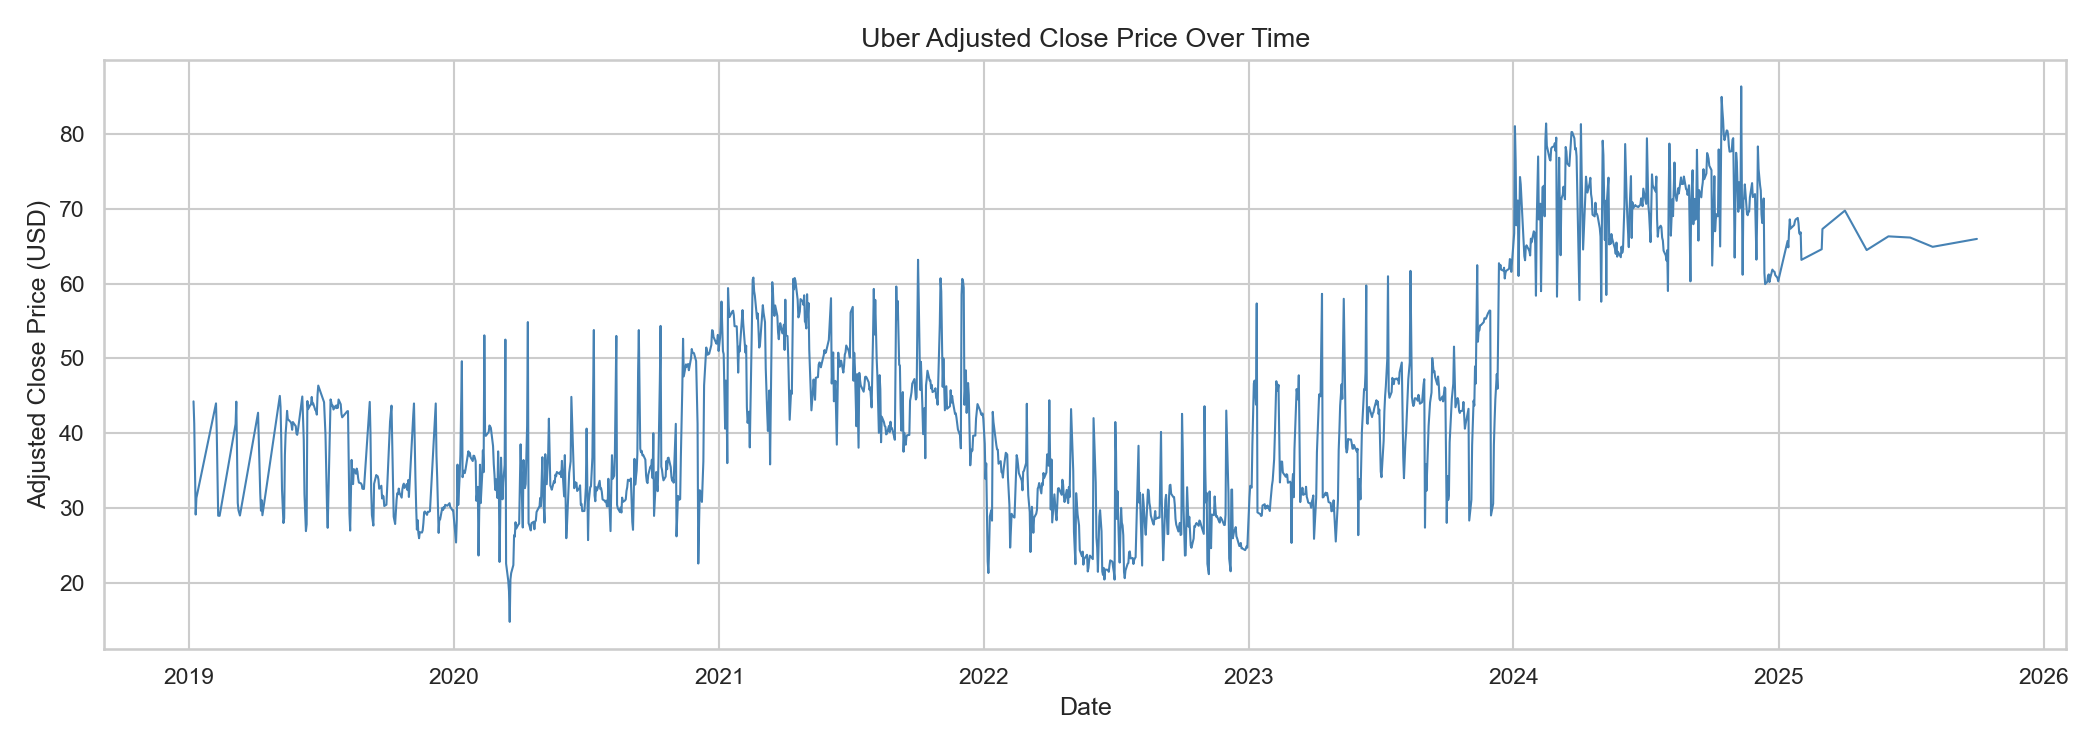

In [3]:
display(Image(filename="../outputs/figures/price_series.png"))

---

## 2️⃣  Return Distributions

Before modelling, we inspect the distribution of daily log-returns.

In an ideal ("textbook") world, daily returns would be **normally distributed**
(a bell curve). In reality, financial returns exhibit:

1. **Fat tails (leptokurtosis):** Extreme daily moves (±5%, ±10%) happen far more
   often than a Normal distribution would predict
2. **Negative skew:** Large negative days (crashes) tend to be more extreme than
   large positive days
3. **Excess kurtosis:** The distribution is "taller and thinner" in the centre
   but "heavier" at the tails than a Normal

The Jarque-Bera test formalises this — it tests whether skewness and kurtosis
match the Normal distribution. We expect to strongly reject normality for UBER.

**Why it matters:**  
If we assumed Normal returns and used a Normal GARCH model, our Value-at-Risk
estimates would **underestimate** tail losses. The Student-t GARCH model explicitly
accommodates fat tails.

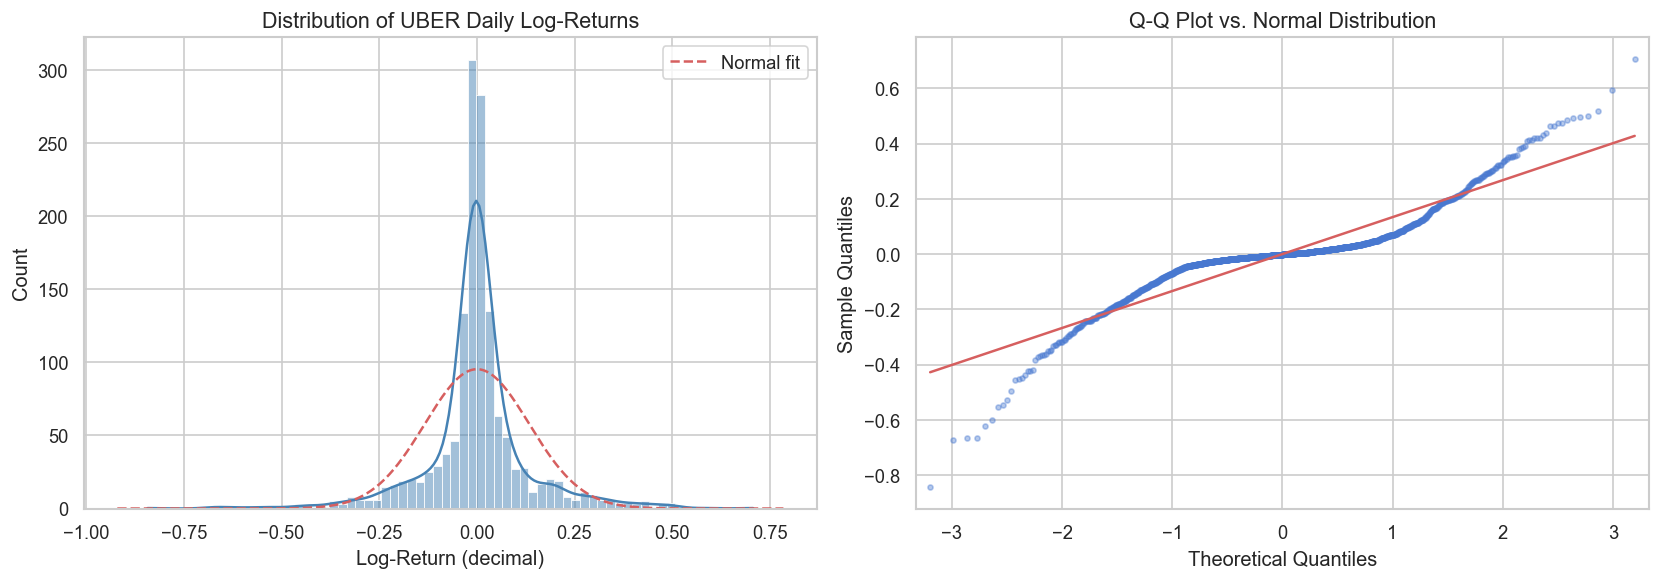


── Return Distribution Summary ─────────────────────────────────────
   Observations : 1,443
   Mean         : 0.000276  (0.0697 annualised)
   Std dev      : 0.133820  (2.1243 annualised)
   Skewness     : -0.2238  (negative = left tail heavier)
   Kurtosis     : 6.0065  (>0 = fatter tails than Normal)
   Min (worst)  : -0.8432  (-84.32%)
   Max (best)   : 0.7075  (70.75%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram + KDE ────────────────────────────────────────────────
r = df["log_return"].dropna()
sns.histplot(r, kde=True, bins=70, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of UBER Daily Log-Returns")
axes[0].set_xlabel("Log-Return (decimal)")
axes[0].set_ylabel("Count")

# Overlay Normal distribution for comparison
from scipy.stats import norm
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 300)
p = norm.pdf(x, r.mean(), r.std()) * len(r) * (r.max() - r.min()) / 70
axes[0].plot(x, p, "r--", linewidth=1.5, label="Normal fit")
axes[0].legend()

# ── Right: Q-Q plot ───────────────────────────────────────────────────────
from statsmodels.graphics.gofplots import qqplot
qqplot(r, line="s", ax=axes[1], alpha=0.4, markersize=3)
axes[1].set_title("Q-Q Plot vs. Normal Distribution")
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────
print(f"\n── Return Distribution Summary ─────────────────────────────────────")
print(f"   Observations : {len(r):,}")
print(f"   Mean         : {r.mean():.6f}  ({r.mean()*252:.4f} annualised)")
print(f"   Std dev      : {r.std():.6f}  ({r.std()*np.sqrt(252):.4f} annualised)")
print(f"   Skewness     : {r.skew():.4f}  (negative = left tail heavier)")
print(f"   Kurtosis     : {r.kurt():.4f}  (>0 = fatter tails than Normal)")
print(f"   Min (worst)  : {r.min():.4f}  ({r.min():.2%})")
print(f"   Max (best)   : {r.max():.4f}  ({r.max():.2%})")

---

## 3️⃣  Rolling Volatility — Time-Varying Risk

If Uber's volatility were constant, a single number (e.g. "40% per year") would
fully describe its risk. The rolling volatility chart proves this assumption is wrong.

**Two windows are shown:**
- **21-day (1-month):** Reacts quickly to new shocks — high-frequency signal
- **63-day (1-quarter):** Smoother, shows the sustained volatility regime changes

**Formula:**

The `√252` annualizes the daily standard deviation (252 trading days per year).

**What to look for:**
- The COVID crash spike (Feb–Mar 2020) — should be the single largest vol event
- The sustained elevated vol in 2022 — driven by Fed rate hikes
- The relative calm of 2023–2024 as Uber achieved profitability
- The 21-day line always reacts *before* the 63-day line — this lag is why GARCH
  is more useful than rolling windows for real-time risk management

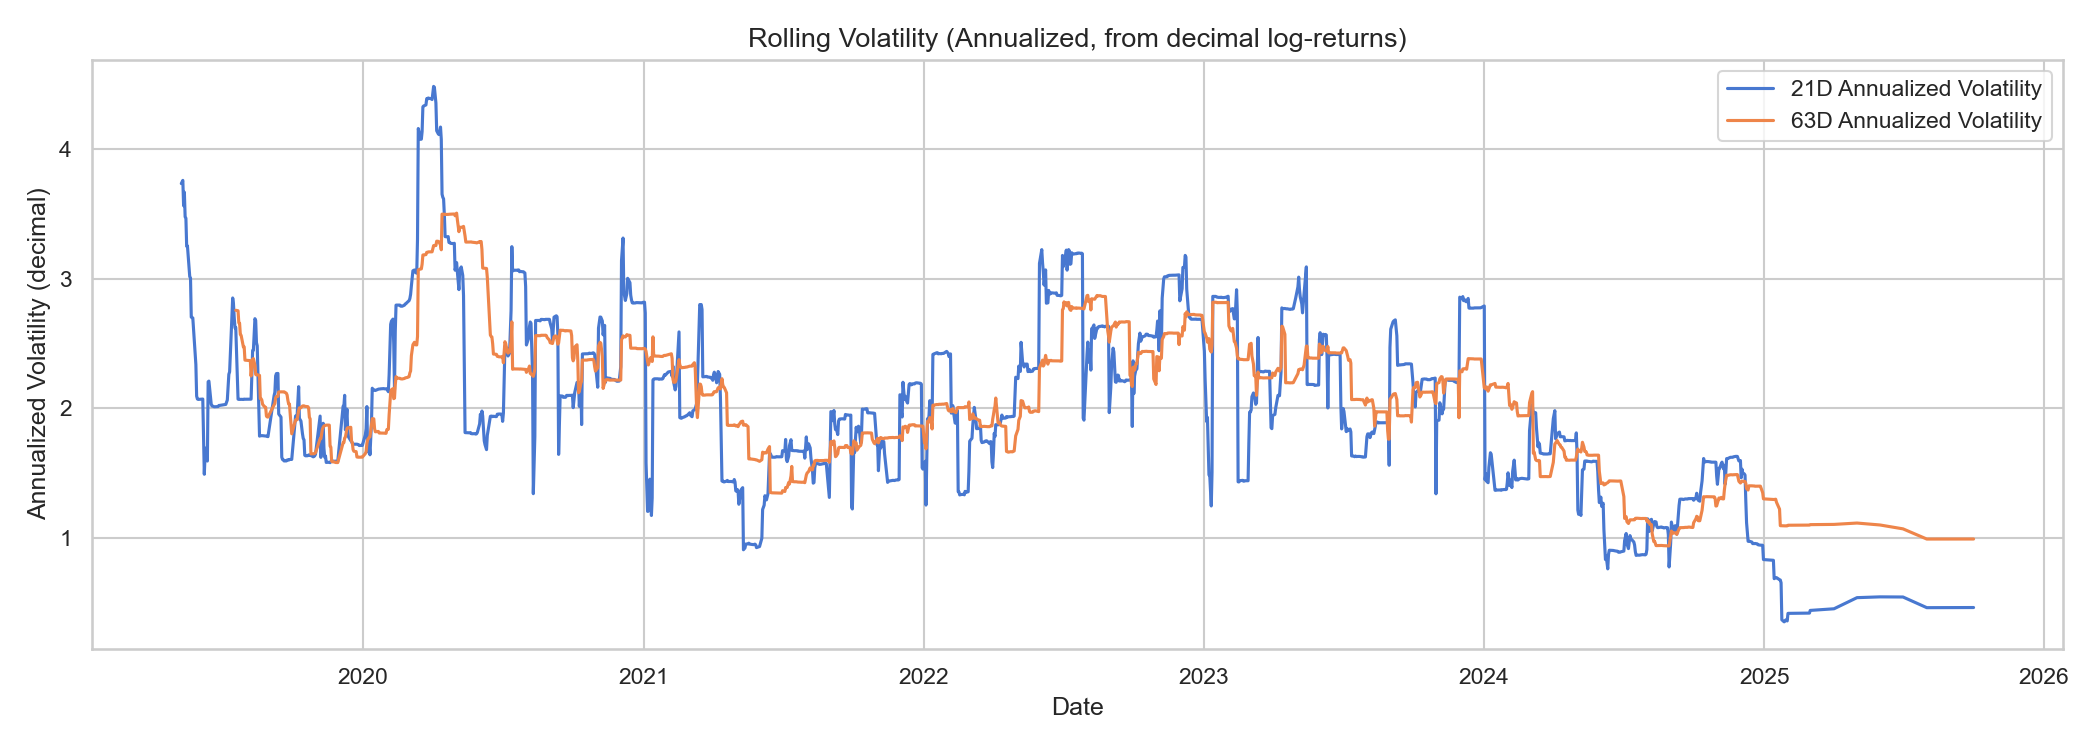

── Volatility Extremes (21-day annualized) ──────────────────────────
   Highest vol day : 2020-04-02  →  448.65%
   Lowest vol day  : 2025-01-27  →  34.95%
   Median vol      : 198.61%
   Current vol     : 46.02%  (last available)

── Volatility by Year ───────────────────────────────────────────────
   2019: 215.66%  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2020: 266.48%  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2021: 176.59%  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [5]:
display(Image(filename="../outputs/figures/rolling_volatility.png"))

# Print the highest and lowest volatility periods
vol_21 = df["vol_21d"].dropna()
print("── Volatility Extremes (21-day annualized) ──────────────────────────")
print(f"   Highest vol day : {vol_21.idxmax().date()}  →  {vol_21.max():.2%}")
print(f"   Lowest vol day  : {vol_21.idxmin().date()}  →  {vol_21.min():.2%}")
print(f"   Median vol      : {vol_21.median():.2%}")
print(f"   Current vol     : {vol_21.iloc[-1]:.2%}  (last available)")
print()
print("── Volatility by Year ───────────────────────────────────────────────")
yearly_vol = (
    df["log_return"]
    .dropna()
    .groupby(df["year"])
    .std()
    .mul(np.sqrt(252))
    .rename("annualized_vol")
)
for yr, vol in yearly_vol.items():
    bar = "█" * int(vol * 100)
    print(f"   {yr}: {vol:.2%}  {bar}")

---

## 4️⃣  Risk Metrics

Standard portfolio risk metrics computed across the **full dataset**.

| Metric | Formula | Meaning |
|---|---|---|
| **CAGR** | `(P_final / P_initial)^(1/years) - 1` | Annualised geometric return |
| **Ann. Volatility** | `std(log_return) × √252` | Annualised standard deviation of daily returns |
| **Sharpe Ratio** | `(CAGR - Rf) / Ann. Vol` | Return per unit of risk (0% risk-free rate used) |
| **VaR 95%** | 5th percentile of daily returns | "On a bad day (1 in 20), the daily loss is at least X%" |
| **CVaR 95%** | Mean return below the VaR threshold | "When it is a bad day, the average loss is X%" |
| **Max Drawdown** | `min(cum_return / rolling_peak - 1)` | The worst peak-to-trough loss over the entire period |

> **Note on CAGR:** This uses the **geometric** (compounding) formula anchored to
> actual starting and ending prices — not the arithmetic mean of daily returns. The
> arithmetic mean approach overstates returns for volatile stocks and is not used
> in professional finance.

  Metric                                     Value  Interpretation
  Annualized Return (CAGR)                +6.10%
  Annualized Volatility                 +212.43%
  Sharpe Ratio (Rf = 0%)                 +1.0675
  VaR 95% (daily)                        -19.48%
  CVaR 95% (daily)                       -28.37%
  Maximum Drawdown                       -72.09%


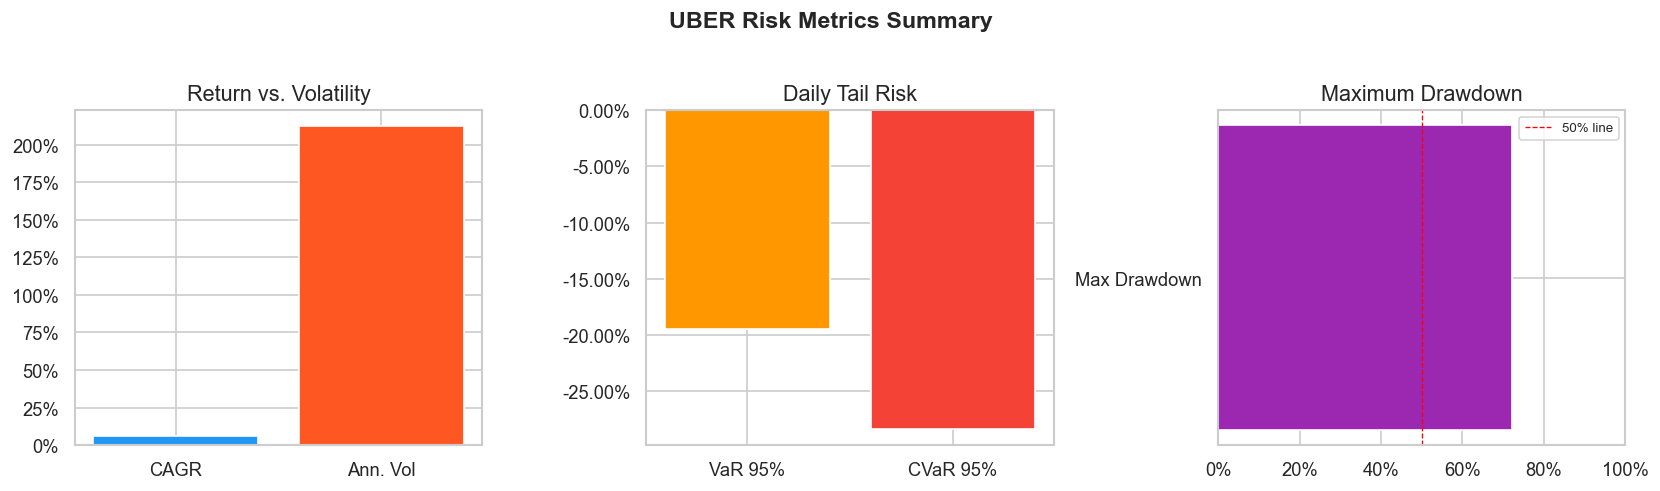

In [6]:
risk = metrics["risk_metrics"]

metrics_display = [
    ("Annualized Return (CAGR)",  risk["annualized_return"],  "percent"),
    ("Annualized Volatility",     risk["annualized_volatility"], "percent"),
    ("Sharpe Ratio (Rf = 0%)",    risk["sharpe_ratio"],       "ratio"),
    ("VaR 95% (daily)",           risk["VaR_95_daily"],       "percent"),
    ("CVaR 95% (daily)",          risk["CVaR_95_daily"],      "percent"),
    ("Maximum Drawdown",          risk["max_drawdown"],       "percent"),
]

print("=" * 62)
print(f"  {'Metric':<35} {'Value':>12}  Interpretation")
print("=" * 62)
for name, val, fmt in metrics_display:
    if fmt == "percent":
        formatted = f"{val:>+10.2%}"
    else:
        formatted = f"{val:>+10.4f}"
    print(f"  {name:<35} {formatted}")
print("=" * 62)

# ── Visual bar chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Return vs Volatility
axes[0].bar(["CAGR", "Ann. Vol"],
            [risk["annualized_return"], risk["annualized_volatility"]],
            color=["#2196F3", "#FF5722"])
axes[0].set_title("Return vs. Volatility")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# 2. Tail Risk
axes[1].bar(["VaR 95%", "CVaR 95%"],
            [risk["VaR_95_daily"], risk["CVaR_95_daily"]],
            color=["#FF9800", "#F44336"])
axes[1].set_title("Daily Tail Risk")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2%}"))

# 3. Max drawdown gauge
axes[2].barh(["Max Drawdown"], [abs(risk["max_drawdown"])],
             color="#9C27B0")
axes[2].set_xlim(0, 1)
axes[2].set_title("Maximum Drawdown")
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[2].axvline(0.5, color="red", linestyle="--", linewidth=0.8, label="50% line")
axes[2].legend(fontsize=8)

plt.suptitle("UBER Risk Metrics Summary", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## 5️⃣  Statistical Tests on Log-Returns

Four tests give us a complete statistical picture of the return series before
building a model:

| Test | What It Asks | Expected Result for UBER |
|---|---|---|
| **ADF (stationarity)** | Does the series have a unit root (random walk)? | Reject H₀ — log-returns ARE stationary |
| **Jarque-Bera (normality)** | Are skewness and kurtosis consistent with Normal? | Reject H₀ — returns are NOT Normal |
| **Ljung-Box (autocorrelation)** | Are there linear patterns (autocorrelation) in returns? | May or may not reject — markets are often near-efficient |
| **ARCH LM (volatility clustering)** | Does squared-return autocorrelation exist? | Strongly reject H₀ — ARCH effects ARE present |

The ARCH test is the **gateway test for GARCH**: if it fails to reject, there are
no volatility clusters and a constant-variance model is sufficient. Almost all
liquid equity stocks (including UBER) strongly exhibit ARCH effects.

In [7]:
diag = metrics["diagnostics"]

def verdict(p, threshold=0.05, reject_msg="Reject H₀", fail_msg="Fail to reject H₀"):
    icon = "✅" if p < threshold else "⚠️ "
    return f"{icon}  {reject_msg if p < threshold else fail_msg}  (p = {p:.2e})"

print("═" * 68)
print("  Statistical Tests on UBER Daily Log-Returns")
print("═" * 68)

# ── ADF ──────────────────────────────────────────────────────────────────
adf = diag["adf"]
print(f"\n  1. ADF Stationarity Test")
print(f"     H₀ : log-returns have a unit root (non-stationary)")
print(f"     Stat    : {adf['stat']:.4f}")
print(f"     Result  : {verdict(adf['p_value'], reject_msg='Log-returns ARE stationary ← good for modelling', fail_msg='Non-stationary — investigate')}")

# ── Jarque-Bera ───────────────────────────────────────────────────────────
jb = diag["jarque_bera"]
print(f"\n  2. Jarque-Bera Normality Test")
print(f"     H₀ : returns are Normally distributed")
print(f"     Stat    : {jb['stat']:.2f}")
print(f"     Result  : {verdict(jb['p_value'], reject_msg='Returns are NOT Normal — fat tails confirmed', fail_msg='Cannot reject Normality')}")
r = df["log_return"].dropna()
print(f"     Skewness  : {r.skew():.4f}  |  Kurtosis: {r.kurt():.4f}")

# ── Ljung-Box ─────────────────────────────────────────────────────────────
print(f"\n  3. Ljung-Box Autocorrelation Test")
print(f"     H₀ : no autocorrelation in log-returns")
for lag_str, lb_vals in diag["ljung_box"].items():
    p_lb = lb_vals["lb_pvalue"]
    lv   = verdict(p_lb, reject_msg=f"Autocorrelation at lag {lag_str}", fail_msg=f"No significant autocorrelation at lag {lag_str}")
    print(f"     Lag {lag_str:>2}  : {lv}")

# ── ARCH ─────────────────────────────────────────────────────────────────
arch = diag["arch_test"]
print(f"\n  4. ARCH LM Volatility Clustering Test")
print(f"     H₀ : no ARCH effects (constant variance)")
print(f"     Stat    : {arch['stat']:.4f}")
print(f"     Result  : {verdict(arch['p_value'], reject_msg='ARCH effects CONFIRMED — GARCH is justified ✅', fail_msg='No ARCH effects detected')}")
print()
print("═" * 68)

════════════════════════════════════════════════════════════════════
  Statistical Tests on UBER Daily Log-Returns
════════════════════════════════════════════════════════════════════

  1. ADF Stationarity Test
     H₀ : log-returns have a unit root (non-stationary)
     Stat    : -10.2800
     Result  : ✅  Log-returns ARE stationary ← good for modelling  (p = 3.80e-18)

  2. Jarque-Bera Normality Test
     H₀ : returns are Normally distributed
     Stat    : 2163.25
     Result  : ✅  Returns are NOT Normal — fat tails confirmed  (p = 0.00e+00)
     Skewness  : -0.2238  |  Kurtosis: 6.0065

  3. Ljung-Box Autocorrelation Test
     H₀ : no autocorrelation in log-returns
     Lag 10  : ✅  Autocorrelation at lag 10  (p = 2.65e-18)
     Lag 20  : ✅  Autocorrelation at lag 20  (p = 5.70e-15)

  4. ARCH LM Volatility Clustering Test
     H₀ : no ARCH effects (constant variance)
     Stat    : 51.4096
     Result  : ✅  ARCH effects CONFIRMED — GARCH is justified ✅  (p = 1.47e-07)

══════════

---

## 6️⃣  Why GARCH? — The Intuition

The rolling volatility chart already *shows* that volatility is not constant. The
ARCH test *proves* it statistically. Now we understand *why* that matters.

### The Problem With Rolling Windows

Rolling standard deviation (e.g. `vol_21d`) is simple and intuitive, but it has
a critical flaw: it weights every day equally within the window. A return from
21 trading days ago (one month) gets the same weight as yesterday's return.

This means:
- **It reacts slowly** — it takes days to register a new shock
- **It forgets abruptly** — when a large event "falls out of the window", vol
  drops sharply even if nothing has changed

### What GARCH Does Differently

GARCH uses **exponentially decaying weights** — recent observations get far more
weight than older ones. The model's variance equation:

has an elegant interpretation:
- `ω` is the floor — variance can never go below this baseline
- `α · ε²_{t-1}` is the **shock term** — yesterday's surprise scaled by α
- `β · σ²_{t-1}` is the **memory term** — yesterday's variance scaled by β

When `α + β` is close to 1 (as is typical for equities), the model has a very
long memory — a large shock takes many days to fade. This matches observed
market behaviour.

### The GARCH(1,1)-AR(1) Specification Used Here

The AR(1) mean equation captures any mild autocorrelation in returns (which the
Ljung-Box test may have detected). The Student-t distribution with degrees-of-freedom
parameter `ν` handles fat tails — when `ν` is small (e.g. 4–6), tails are much
heavier than Normal.

### Input: `log_return_pct` (not `log_return`)

The GARCH model is fed **percentage log-returns** (e.g. `2.3` for a +2.3% day)
rather than decimal returns (e.g. `0.023`). This is purely numerical — it keeps
the variance `σ²` in a human-readable range (~0.5–5.0) instead of (~0.00005–0.0005),
which helps the optimizer converge reliably. All outputs are converted back to
decimal annualised form for reporting.

In [8]:
gm = metrics["garch_metrics"]

print("═" * 70)
print("  GARCH(1,1)-AR(1) — Fitted Parameters  (training set)")
print("═" * 70)

rows = [
    ("ω  omega (intercept)",       gm["omega"],         "float6",  "Baseline variance — the floor. Always > 0."),
    ("α  alpha (ARCH / shock)",    gm["alpha_1"],        "float4",  "Weight on yesterday's squared shock ε²_{t-1}."),
    ("β  beta  (GARCH / memory)",  gm["beta_1"],         "float4",  "Weight on yesterday's variance σ²_{t-1}."),
    ("α + β  persistence",         gm["persistence"],    "float4",
     "< 1 = mean-reverting  |  near 1 = slow decay"),
    ("Unconditional vol (ann.)",   gm["unconditional_vol_ann"], "percent",
     "Long-run avg vol = √(ω/(1-α-β)) × √252 annualised"),
    ("Last in-sample cond. vol",   gm["last_cond_vol_ann"],     "percent",
     "Model's annualised vol estimate at end of training"),
    ("AIC",                        gm["aic"],            "float2",  "Lower = better model fit"),
    ("BIC",                        gm["bic"],            "float2",  "Lower = better (penalises complexity more than AIC)"),
    ("Log-Likelihood",             gm["log_likelihood"], "float2",  "Higher = better in-sample fit"),
    ("Train observations",         gm["n_train"],        "int",     "Days used to fit the model (first 80%)"),
    ("Test  observations",         gm["n_test"],         "int",     "Days held out for OOS evaluation (last 20%)"),
]

print(f"\n  {'Parameter':<35} {'Value':>12}   Interpretation")
print(f"  {'─'*35} {'─'*12}   {'─'*35}")
for name, val, fmt, interp in rows:
    if   fmt == "float6":  fv = f"{val:>12.6f}"
    elif fmt == "float4":  fv = f"{val:>12.4f}"
    elif fmt == "float2":  fv = f"{val:>12.2f}"
    elif fmt == "percent": fv = f"{val:>12.2%}" if val and not (isinstance(val, float) and np.isnan(val)) else f"{'N/A':>12}"
    else:                  fv = f"{int(val):>12}"
    print(f"  {name:<35} {fv}   {interp}")

print()

# ── Persistence interpretation ────────────────────────────────────────────
p = gm["persistence"]
if p >= 0.97:
    label = "VERY HIGH — shocks take months to fully decay (IGARCH-like)"
elif p >= 0.90:
    label = "HIGH — shocks typically take 2–4 weeks to decay"
elif p >= 0.80:
    label = "MODERATE — shocks decay within 1–2 weeks"
else:
    label = "LOW — shocks decay quickly (< 1 week)"
print(f"  Persistence interpretation: {label}")

══════════════════════════════════════════════════════════════════════
  GARCH(1,1)-AR(1) — Fitted Parameters  (training set)
══════════════════════════════════════════════════════════════════════

  Parameter                                  Value   Interpretation
  ─────────────────────────────────── ────────────   ───────────────────────────────────
  ω  omega (intercept)                   24.398276   Baseline variance — the floor. Always > 0.
  α  alpha (ARCH / shock)                   0.7008   Weight on yesterday's squared shock ε²_{t-1}.
  β  beta  (GARCH / memory)                 0.2992   Weight on yesterday's variance σ²_{t-1}.
  α + β  persistence                        1.0000   < 1 = mean-reverting  |  near 1 = slow decay
  Unconditional vol (ann.)                     N/A   Long-run avg vol = √(ω/(1-α-β)) × √252 annualised
  Last in-sample cond. vol                 202.32%   Model's annualised vol estimate at end of training
  AIC                                      8564.39 

---

## 7️⃣  In-Sample Fit — Did GARCH Capture the Volatility Clusters?

The model was fitted on the **first 80%** of the data (the training set). The
in-sample conditional volatility `σ_t` tells us: *"given everything up to day t-1,
what did the model estimate the daily volatility to be on day t?"*

**The two-panel chart shows:**

**Top panel — Returns with GARCH bands:**
- Grey/blue: raw daily log-returns (decimal)
- Orange shading: ±1σ GARCH daily volatility bands (in-sample, training period only)
- If the model is well-calibrated, ~68% of returns should fall inside the bands

**Bottom panel — Conditional volatility over time:**
- Orange: in-sample GARCH conditional vol (annualised, training set)
- Red dashed: OOS 1-step-ahead forecasted vol (test set — the model never saw this data)
- Grey: `|log_return|` as a noisy proxy for realised daily volatility

**Key question:** Does the orange line rise sharply during crisis periods and
fall during calm periods? If yes, GARCH is doing its job.

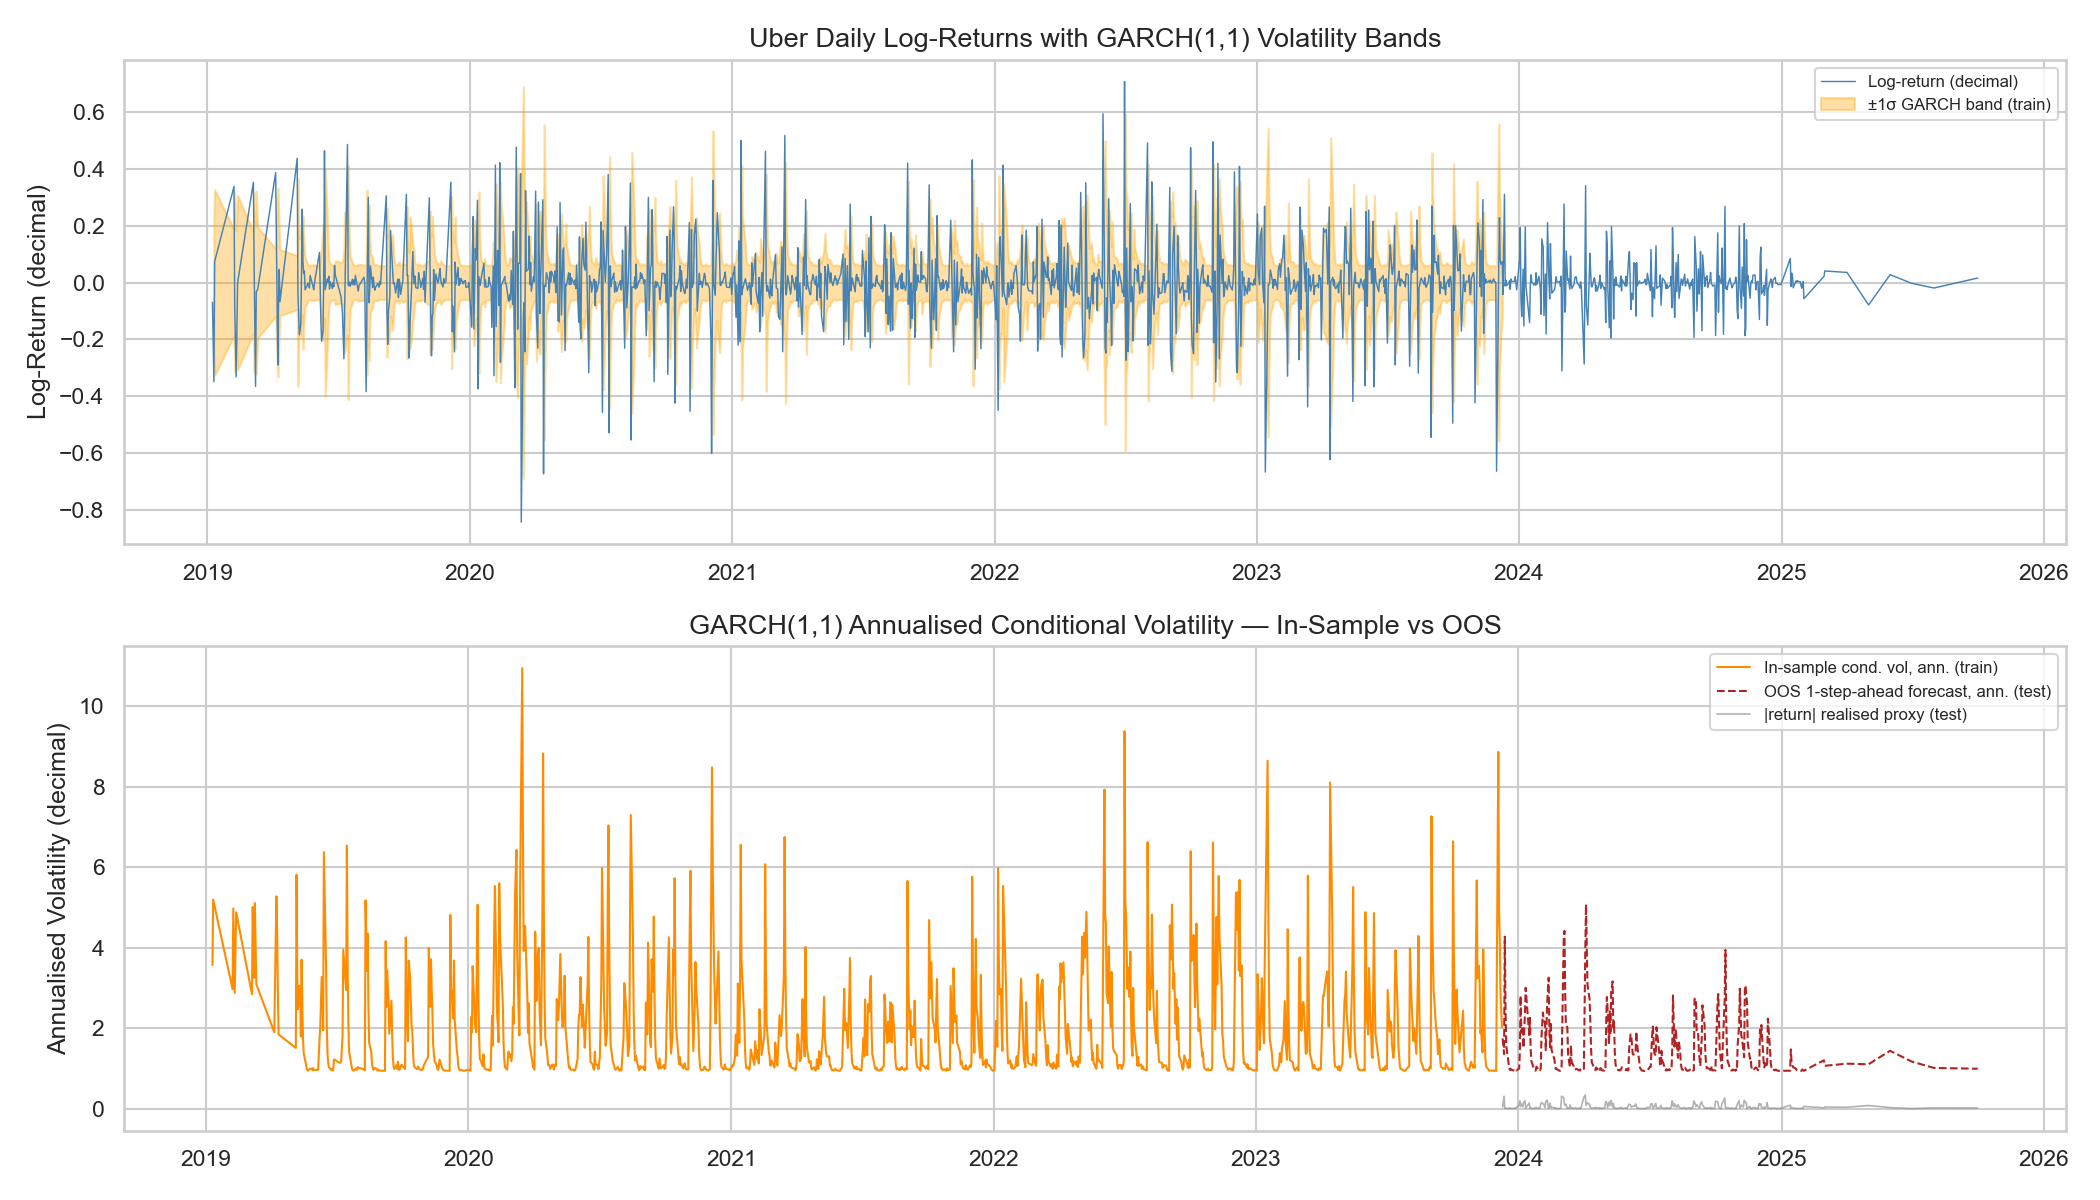

  Training set end-of-period cond. vol : 202.32%  (annualised)
  Unconditional (long-run) vol         : nan%  (annualised)

  Peak in-sample cond. vol             : 1094.37%  on 2020-03-16
  Trough in-sample cond. vol           : 93.80%  on 2023-12-01


In [9]:
display(Image(filename="../outputs/figures/garch_conditional_volatility.png"))

# ── Spot-check: what was the model's conditional vol during COVID? ─────────
gm = metrics["garch_metrics"]
print(f"  Training set end-of-period cond. vol : {gm['last_cond_vol_ann']:.2%}  (annualised)")
print(f"  Unconditional (long-run) vol         : {gm['unconditional_vol_ann']:.2%}  (annualised)")
print()
cond_vol_pct = garch_result.conditional_volatility          # pct/day (training set)
cond_vol_ann = (cond_vol_pct / 100.0) * np.sqrt(252)
print(f"  Peak in-sample cond. vol             : {cond_vol_ann.max():.2%}  "
      f"on {cond_vol_ann.idxmax().date()}")
print(f"  Trough in-sample cond. vol           : {cond_vol_ann.min():.2%}  "
      f"on {cond_vol_ann.idxmin().date()}")

---

## 8️⃣  Out-of-Sample (OOS) Evaluation

**The most important test** of any model is whether it works on data it has
never seen. The OOS setup:

1. GARCH parameters are **frozen** after training on the first 80%
2. For each day in the test set (last 20%), the model runs the GARCH recursion
   forward using only the training-set parameters — this is called
   **"walk-forward without re-estimation"**
3. The 1-step-ahead variance forecast is compared to `|log_return|` — the
   absolute return on that day, which is a standard (if noisy) proxy for
   realised daily volatility

**Why is `|return|` a noisy proxy?**  
True realised volatility on a single day can only be precisely estimated using
intraday tick data. `|return|` is a biased estimator — a day with a return of
exactly 0% would show `|return|` = 0 even if intraday swings were large. It
is, however, unbiased in expectation and is the standard proxy for daily
volatility in academic literature when tick data is unavailable.

**Evaluation metrics:**

| Metric | Meaning | What to Expect |
|---|---|---|
| **OOS MAE (vol)** | Mean absolute error between forecast and `\|return\|`, annualised | Will be ~0.01–0.03 in decimal ann. vol units |
| **OOS Correlation** | Pearson correlation between predicted and realised vol | Even 0.05–0.15 is meaningful for individual equities |

A positive correlation confirms the model is **directionally correct** — it
forecasts higher vol when vol is actually higher, and lower vol when it is
actually lower. This is what matters for risk management applications.

════════════════════════════════════════════════════════════
  GARCH(1,1) — Out-of-Sample Evaluation
════════════════════════════════════════════════════════════
  Train : 1154 days  |  Test : 289 days

  OOS MAE (vol)    : 1.3873  (ann. decimal units)
  OOS Correlation  : 0.4235

  Interpretation   : ✅  Good directional accuracy for an individual equity

  Note: |return| is a noisy proxy. Correlations of 0.05–0.20
  are typical and meaningful for equity vol forecasting.
════════════════════════════════════════════════════════════


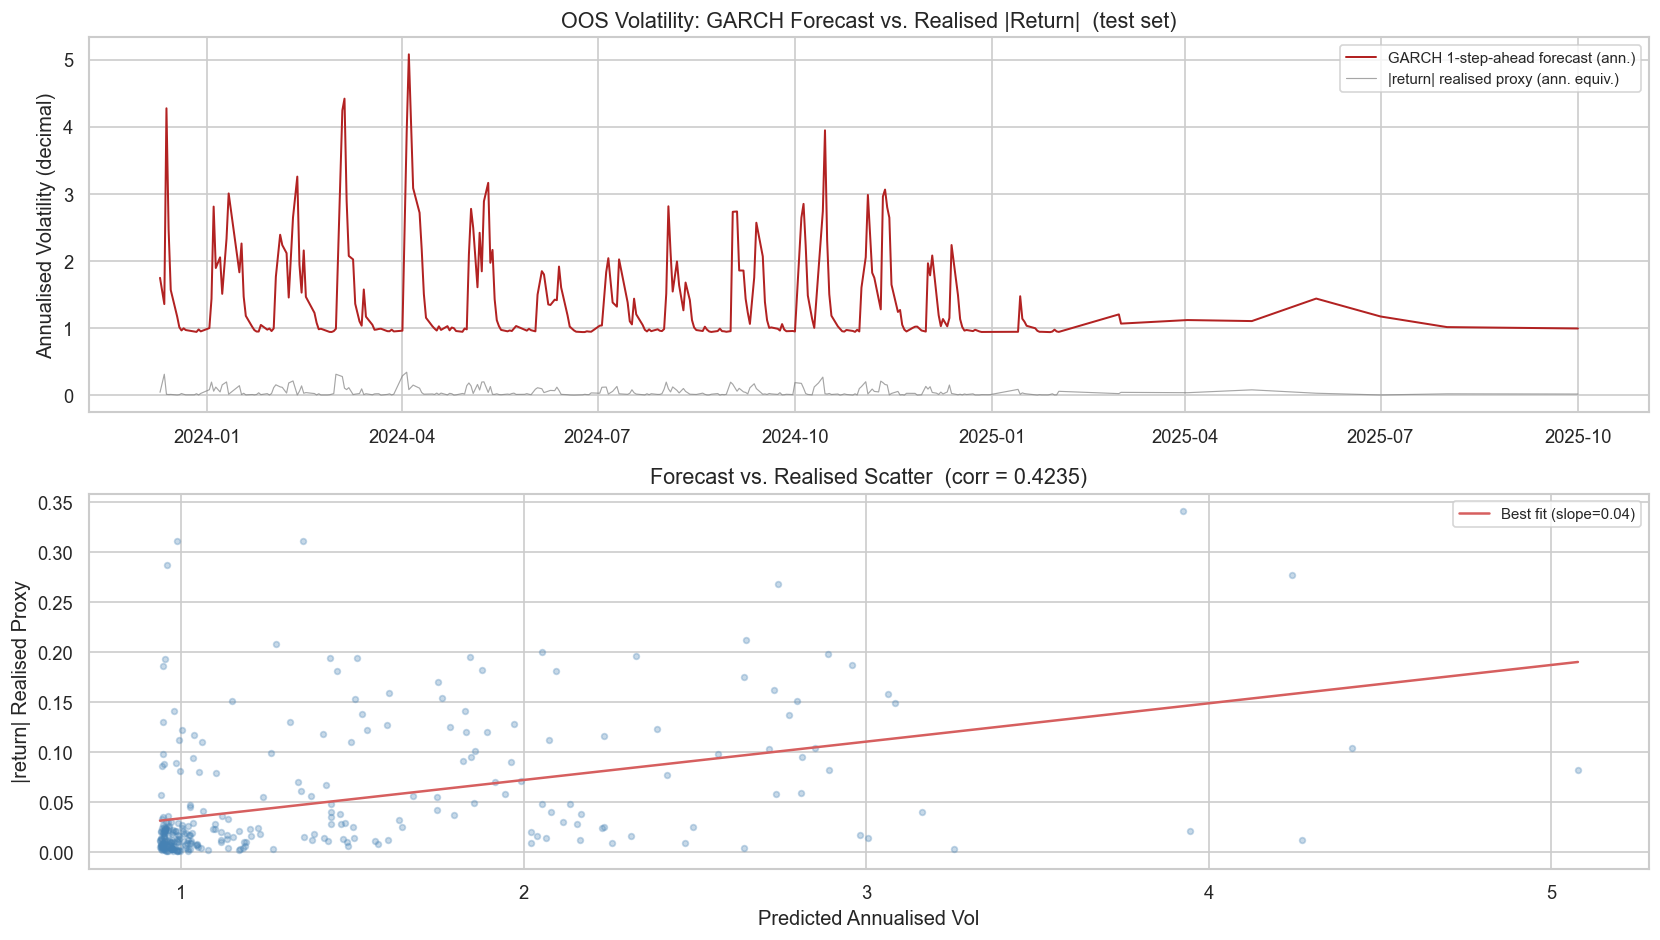

In [10]:
gm = metrics["garch_metrics"]

# ── Print OOS metrics ─────────────────────────────────────────────────────
print("═" * 60)
print("  GARCH(1,1) — Out-of-Sample Evaluation")
print("═" * 60)
print(f"  Train : {gm['n_train']} days  |  Test : {gm['n_test']} days")
print()
print(f"  OOS MAE (vol)    : {gm['oos_mae_vol']:.4f}  (ann. decimal units)")
print(f"  OOS Correlation  : {gm['oos_corr_vol']:.4f}")

corr = gm['oos_corr_vol']
if corr >= 0.15:
    interp = "✅  Good directional accuracy for an individual equity"
elif corr >= 0.05:
    interp = "✅  Modest but positive directional accuracy (typical)"
elif corr >= 0.0:
    interp = "⚠️   Near-zero but positive — model is weakly informative"
else:
    interp = "❌  Negative correlation — model may be mis-specified"
print(f"\n  Interpretation   : {interp}")
print()
print("  Note: |return| is a noisy proxy. Correlations of 0.05–0.20")
print("  are typical and meaningful for equity vol forecasting.")
print("═" * 60)

# ── Load OOS data and plot ─────────────────────────────────────────────────
oos_df = pd.read_csv(
    "../outputs/tables/garch_oos_volatility.csv",
    index_col=0, parse_dates=True
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: time series comparison
axes[0].plot(oos_df.index, oos_df["predicted_vol_ann"],
             color="firebrick", linewidth=1.2, label="GARCH 1-step-ahead forecast (ann.)")
axes[0].plot(oos_df.index, oos_df["realized_vol_proxy"],
             color="grey", linewidth=0.7, alpha=0.7, label="|return| realised proxy (ann. equiv.)")
axes[0].set_title("OOS Volatility: GARCH Forecast vs. Realised |Return|  (test set)")
axes[0].set_ylabel("Annualised Volatility (decimal)")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Bottom: scatter plot
axes[1].scatter(oos_df["predicted_vol_ann"], oos_df["realized_vol_proxy"],
                alpha=0.3, s=12, color="steelblue")
# Fit line
m, b = np.polyfit(oos_df["predicted_vol_ann"], oos_df["realized_vol_proxy"], 1)
x_line = np.linspace(oos_df["predicted_vol_ann"].min(), oos_df["predicted_vol_ann"].max(), 100)
axes[1].plot(x_line, m * x_line + b, "r-", linewidth=1.5,
             label=f"Best fit (slope={m:.2f})")
axes[1].set_title(f"Forecast vs. Realised Scatter  (corr = {gm['oos_corr_vol']:.4f})")
axes[1].set_xlabel("Predicted Annualised Vol")
axes[1].set_ylabel("|return| Realised Proxy")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
print("── First 10 rows of OOS forecast table ──────────────────────────────")
print("   predicted_vol_ann : GARCH 1-step forecast (annualised decimal)")
print("   realized_vol_proxy: |log_return| on that day (decimal)\n")
display(oos_df.head(10).round(4))

print("\n── Last 10 rows (most recent test period) ────────────────────────────")
display(oos_df.tail(10).round(4))

print(f"\n── Summary statistics ──────────────────────────────────────────────")
display(oos_df.describe().round(4))

── First 10 rows of OOS forecast table ──────────────────────────────
   predicted_vol_ann : GARCH 1-step forecast (annualised decimal)
   realized_vol_proxy: |log_return| on that day (decimal)



,predicted_vol_ann,realized_vol_proxy
Date,,
2023-12-10,1.7471,0.0420
2023-12-12,1.3562,0.3111
2023-12-13,4.2731,0.0120
2023-12-14,2.4707,0.0085
2023-12-15,1.5666,0.0103
2023-12-18,1.1696,0.0021
2023-12-19,1.0124,0.0063
2023-12-20,0.9636,0.0235
2023-12-21,0.9949,0.0128



── Last 10 rows (most recent test period) ────────────────────────────


,predicted_vol_ann,realized_vol_proxy
Date,,
2025-01-31,0.9489,0.0039
2025-02-01,0.9418,0.0566
2025-03-01,1.2027,0.0222
2025-03-02,1.0653,0.0410
2025-04-02,1.1183,0.0359
2025-05-02,1.1031,0.0786
2025-06-01,1.4384,0.0280
2025-07-01,1.1714,0.0024
2025-08-01,1.0131,0.0189



── Summary statistics ──────────────────────────────────────────────


,predicted_vol_ann,realized_vol_proxy
count,289.0000,289.0000
mean,1.4375,0.0502
std,0.7148,0.0647
min,0.9386,0.0002
25%,0.9694,0.0087
50%,1.0533,0.0206
75%,1.6773,0.0705
max,5.0772,0.3412


---

## 9️⃣  Future Volatility Forecast (5 Trading Days Ahead)

For the **future forecast**, the pipeline re-fits GARCH on the **full dataset**
(all available data, not just the training 80%). This ensures the forecast
incorporates the most recent information, including the last observed return.

**How multi-step forecasts work:**

The GARCH variance recursion for future horizons `h > 1`:

For `h ≥ 2`, the forecast is a **mean-reversion** toward the unconditional variance.
The speed of mean-reversion is governed by `(α+β)^{h-1}`:
- If α+β = 0.95 and h = 5: the weight is 0.95⁴ = 0.81 → still very close to Day 1
- If α+β = 0.70 and h = 5: the weight is 0.70⁴ = 0.24 → most of the shock has faded

**In practice:** For high-persistence equity models (α+β > 0.90), the 5-day
forecast will be nearly identical to the 1-day forecast — the model believes the
current volatility regime will persist for at least a week.

════════════════════════════════════════════════════════════
  GARCH(1,1) — 5-Day-Ahead Volatility Forecast
  (refitted on full dataset)
════════════════════════════════════════════════════════════

  Day     Date            Forecast (ann.)     Note
  ──────  ──────────────  ──────────────────  ──────────────────────────────
  Day 1    2025-10-02      81.97%            ← uses actual last residual
  Day 2    2025-10-03      105.79%            ← pure mean-reversion
  Day 3    2025-10-06      124.92%            ← pure mean-reversion
  Day 4    2025-10-07      141.49%            ← pure mean-reversion
  Day 5    2025-10-08      156.31%            ← pure mean-reversion


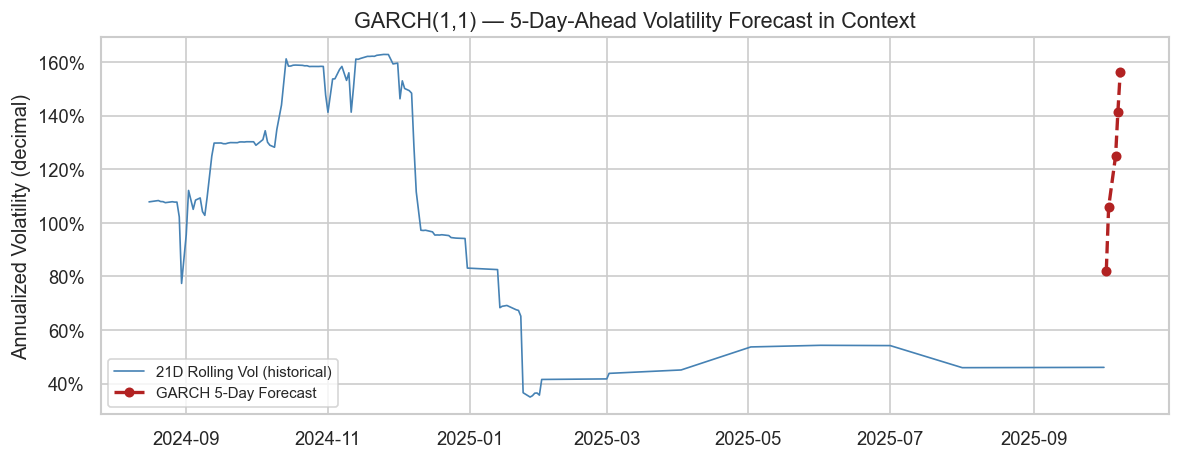

In [12]:
forecast_df = pd.read_csv(
    "../outputs/tables/garch_volatility_forecast.csv",
    index_col=0, parse_dates=True
)

gm = metrics["garch_metrics"]
uncond = gm.get("unconditional_vol_ann")

print("═" * 60)
print("  GARCH(1,1) — 5-Day-Ahead Volatility Forecast")
print("  (refitted on full dataset)")
print("═" * 60)
print()
print(f"  {'Day':<6}  {'Date':<14}  {'Forecast (ann.)':<18}  Note")
print(f"  {'─'*6}  {'─'*14}  {'─'*18}  {'─'*30}")

for i, (date, row) in enumerate(forecast_df.iterrows(), start=1):
    vol = row["annualized_vol_forecast"]
    note = "← uses actual last residual" if i == 1 else "← pure mean-reversion"
    print(f"  Day {i:<3}  {str(date.date()):<14}  {vol:.2%}{'':>10}  {note}")

if uncond and not np.isnan(uncond):
    print(f"\n  Long-run unconditional vol : {uncond:.2%}")
    current = forecast_df["annualized_vol_forecast"].iloc[0]
    if current > uncond:
        print(f"  Current regime is ABOVE long-run average — expect gradual mean-reversion downward")
    else:
        print(f"  Current regime is BELOW long-run average — expect gradual mean-reversion upward")

# ── Visual forecast chart ────────────────���────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

# Historical rolling vol as context (last 120 days)
hist_vol = df["vol_21d"].dropna().iloc[-120:]
ax.plot(hist_vol.index, hist_vol.values,
        color="steelblue", linewidth=1.0, label="21D Rolling Vol (historical)")

# Forecast
ax.plot(forecast_df.index, forecast_df["annualized_vol_forecast"].values,
        color="firebrick", linewidth=2.0, marker="o", markersize=5,
        linestyle="--", label="GARCH 5-Day Forecast")

# Unconditional vol line
if uncond and not np.isnan(uncond):
    ax.axhline(uncond, color="orange", linestyle=":", linewidth=1.2,
               label=f"Unconditional vol ({uncond:.1%})")

ax.set_title("GARCH(1,1) — 5-Day-Ahead Volatility Forecast in Context")
ax.set_ylabel("Annualized Volatility (decimal)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---

## 🔟  Model Validation — Residual Diagnostics

A GARCH model is well-specified if and only if its **standardized residuals**
look like white noise:

where `μ_t` is the AR(1) mean forecast and `σ_t` is the GARCH conditional
standard deviation. If the model has captured all the temporal structure,
`ẑ_t` should have:

- **No autocorrelation** (ACF bars within the confidence bands)
- **No remaining ARCH effects** (ACF bars of `ẑ²_t` within bands)

**The two ACF/PACF charts:**

1. **Before GARCH (raw log-returns):** May show significant spikes — especially in
   squared returns (not shown, but the ARCH test detected this)

2. **After GARCH (standardized residuals):** Should show no significant spikes. If
   spikes remain, the model is misspecified — possible remedies are EGARCH or
   GJR-GARCH to capture the **leverage effect** (negative shocks generate more
   volatility than equally-sized positive shocks)

ACF / PACF of Raw Log-Returns  (before GARCH)
───────────────────────────────────────────────────────
Significant spikes indicate temporal structure that the
GARCH model needs to capture.



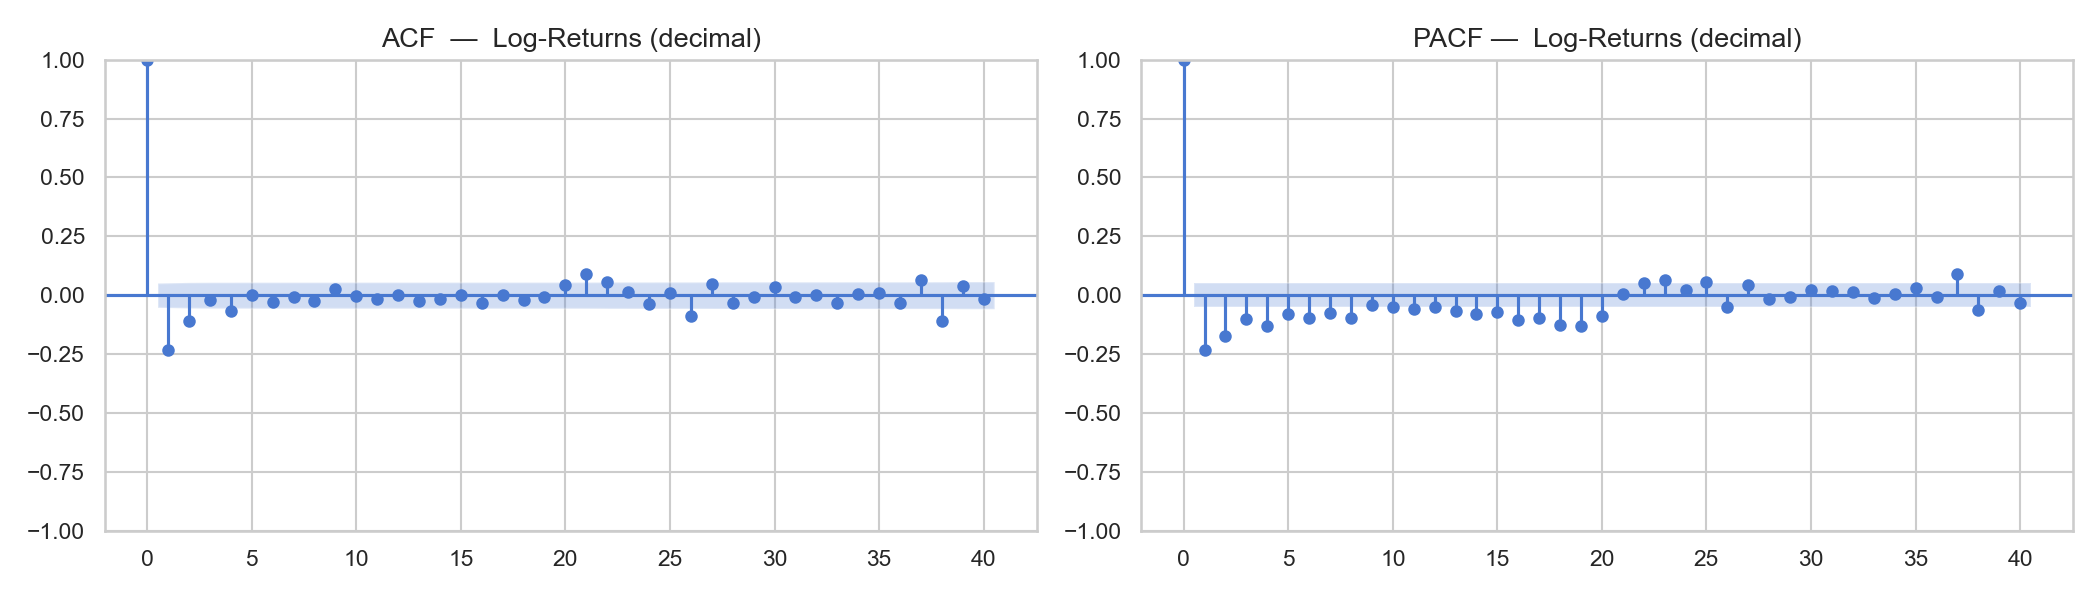

In [13]:
print("ACF / PACF of Raw Log-Returns  (before GARCH)")
print("─" * 55)
print("Significant spikes indicate temporal structure that the")
print("GARCH model needs to capture.\n")

display(Image(filename="../outputs/figures/acf_pacf_returns.png"))

ACF / PACF of GARCH Standardized Residuals  (after GARCH)
────────────────────────────────────────────────────────────
If the model is correctly specified, all bars should fall
within the blue confidence bands (random noise).



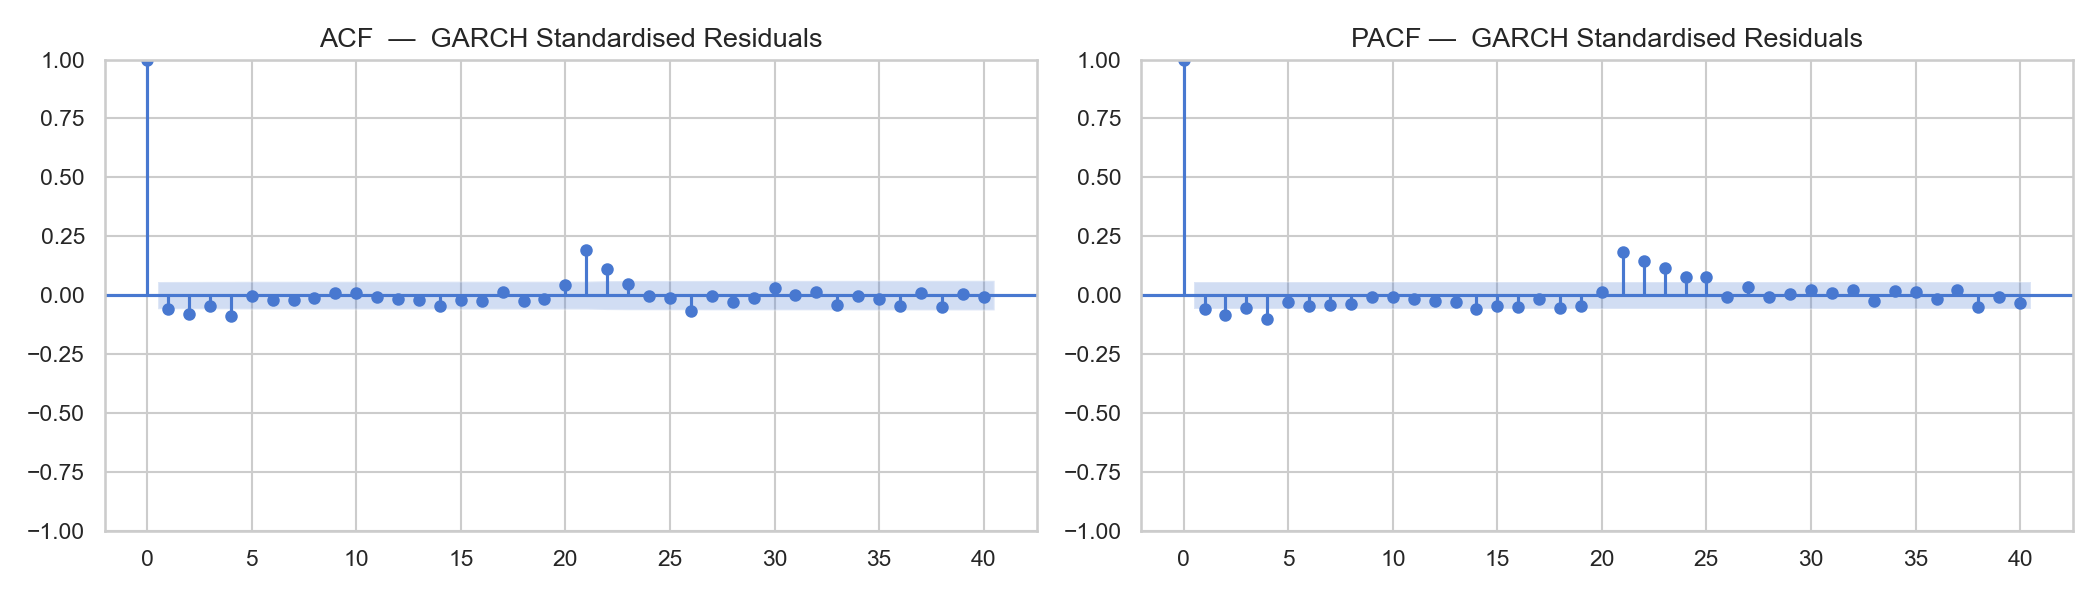


── ARCH LM Test on Standardized Residuals ───────────────────────────
   Stat    : 13.3953
   p-value : 0.2024
   Result  : ✅  No ARCH effects in residuals — GARCH removed the clustering
             The model is correctly specified.


In [14]:
print("ACF / PACF of GARCH Standardized Residuals  (after GARCH)")
print("─" * 60)
print("If the model is correctly specified, all bars should fall")
print("within the blue confidence bands (random noise).\n")

display(Image(filename="../outputs/figures/acf_pacf_residuals.png"))

# ── Re-run ARCH test on standardized residuals ────────────────────────────
from statsmodels.stats.diagnostic import het_arch

std_resid = pd.Series(
    garch_result.std_resid,
    index=df["log_return"].dropna().index[: len(garch_result.std_resid)]
).dropna()

arch_stat_resid, arch_p_resid, *_ = het_arch(std_resid)

print(f"\n── ARCH LM Test on Standardized Residuals ───────────────────────────")
print(f"   Stat    : {arch_stat_resid:.4f}")
print(f"   p-value : {arch_p_resid:.4f}")
if arch_p_resid > 0.05:
    print("   Result  : ✅  No ARCH effects in residuals — GARCH removed the clustering")
    print("             The model is correctly specified.")
else:
    print("   Result  : ⚠️   ARCH effects remain in residuals.")
    print("             Consider: GJR-GARCH (leverage effect) or EGARCH.")

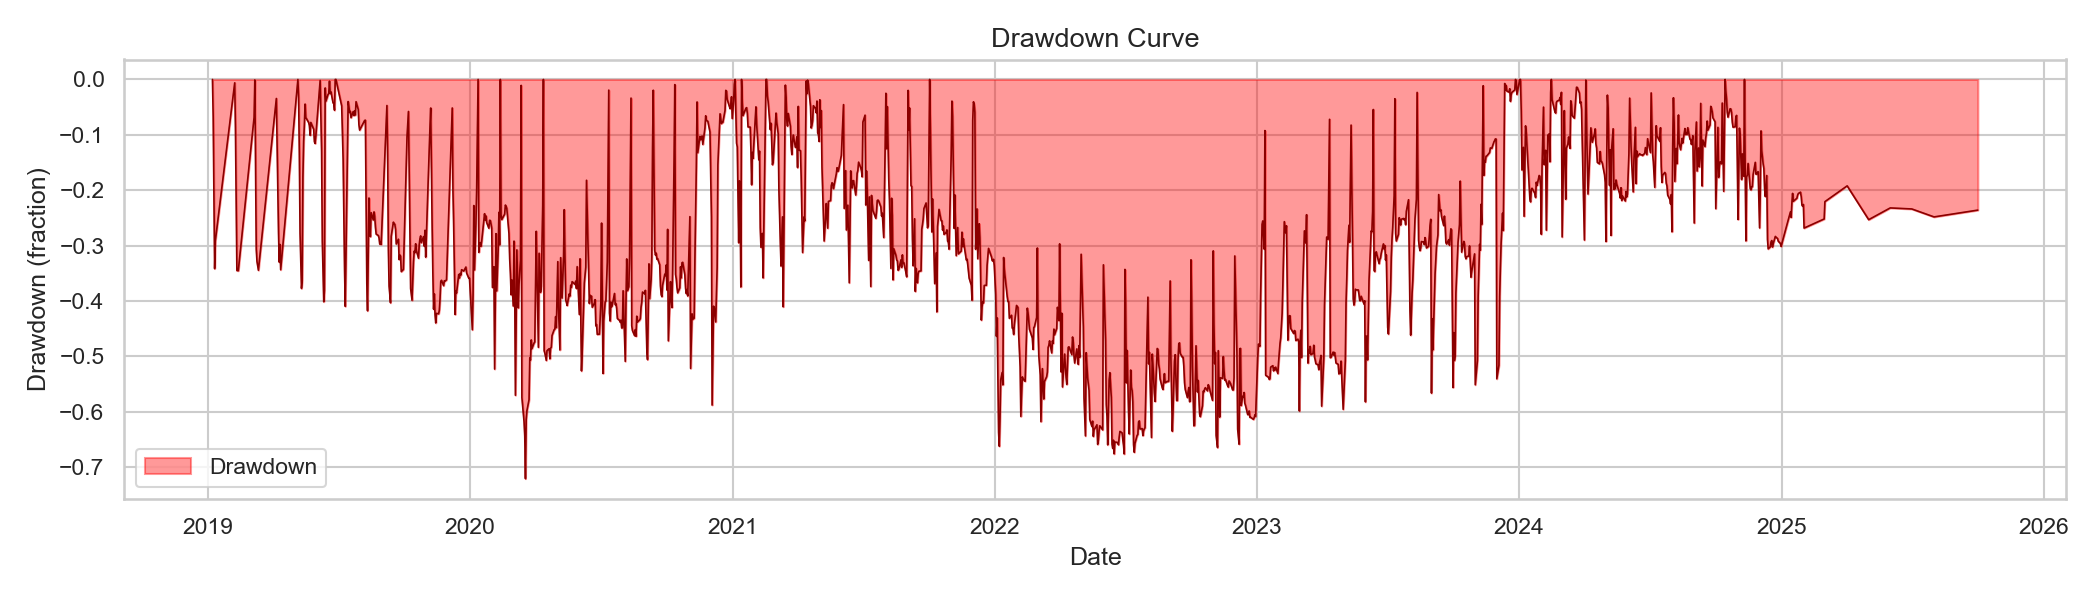

── Drawdown Analysis ────────────────────────────────────────────────
   Maximum drawdown : -72.09%  (on 2020-03-18)

   Days below -10%  : 1201  (83.2% of total history)

   Interpretation:
   Drawdown measures how far the cumulative return is below its peak.
   A reading of -75% means at that point, an investor who bought at
   the peak had lost 75% of their investment.
   Recovery to a new all-time high resets the drawdown to 0.


In [15]:
display(Image(filename="../outputs/figures/drawdown.png"))

max_dd   = metrics["risk_metrics"]["max_drawdown"]
max_dd_date = df["drawdown"].idxmin()

print(f"── Drawdown Analysis ────────────────────────────────────────────────")
print(f"   Maximum drawdown : {max_dd:.2%}  (on {max_dd_date.date()})")
print()
# Recovery analysis
dd = df["drawdown"]
in_drawdown = (dd < -0.10)  # below -10%
total_days_dd = in_drawdown.sum()
print(f"   Days below -10%  : {total_days_dd}  ({total_days_dd/len(df):.1%} of total history)")
print()
print("   Interpretation:")
print("   Drawdown measures how far the cumulative return is below its peak.")
print("   A reading of -75% means at that point, an investor who bought at")
print("   the peak had lost 75% of their investment.")
print("   Recovery to a new all-time high resets the drawdown to 0.")

In [16]:
gm   = metrics["garch_metrics"]
risk = metrics["risk_metrics"]
diag = metrics["diagnostics"]

print("═" * 65)
print("  UBER GARCH(1,1)-AR(1) — Complete Analysis Summary")
print("═" * 65)

print(f"\n  ── Data ──────────────────────────────────────────────────────")
print(f"     Period        : {df.index.min().date()} → {df.index.max().date()}")
print(f"     Trading days  : {len(df):,}")

print(f"\n  ── Price Performance ──────────────────────────────────────────")
print(f"     Start price   : ${df['price'].iloc[0]:.2f}")
print(f"     End price     : ${df['price'].iloc[-1]:.2f}")
print(f"     Total return  : {(df['price'].iloc[-1]/df['price'].iloc[0] - 1):.2%}")
print(f"     CAGR          : {risk['annualized_return']:.2%}")

print(f"\n  ── Risk Metrics ───────────────────────────────────────────────")
print(f"     Ann. Volatility : {risk['annualized_volatility']:.2%}")
print(f"     Sharpe Ratio    : {risk['sharpe_ratio']:.4f}")
print(f"     VaR  95% daily  : {risk['VaR_95_daily']:.2%}")
print(f"     CVaR 95% daily  : {risk['CVaR_95_daily']:.2%}")
print(f"     Max Drawdown    : {risk['max_drawdown']:.2%}")

print(f"\n  ── Statistical Tests ──────────────────────────────────────────")
print(f"     ADF p-value     : {diag['adf']['p_value']:.2e}  ({'stationary' if diag['adf']['p_value'] < 0.05 else 'non-stationary'})")
print(f"     JB  p-value     : {diag['jarque_bera']['p_value']:.2e}  ({'non-normal' if diag['jarque_bera']['p_value'] < 0.05 else 'normal'})")
print(f"     ARCH p-value    : {diag['arch_test']['p_value']:.2e}  ({'clustering confirmed' if diag['arch_test']['p_value'] < 0.05 else 'no clustering'})")

print(f"\n  ── GARCH(1,1) Parameters ──────────────────────────────────────")
print(f"     ω  omega        : {gm['omega']:.6f}")
print(f"     α  alpha        : {gm['alpha_1']:.4f}")
print(f"     β  beta         : {gm['beta_1']:.4f}")
print(f"     α+β persistence : {gm['persistence']:.4f}")
if not np.isnan(gm['unconditional_vol_ann']):
    print(f"     Uncond. vol     : {gm['unconditional_vol_ann']:.2%}  (long-run avg)")
print(f"     Last cond. vol  : {gm['last_cond_vol_ann']:.2%}  (end of training)")
print(f"     AIC / BIC       : {gm['aic']:.1f}  /  {gm['bic']:.1f}")

print(f"\n  ── OOS Evaluation ─────────────────────────────────────────────")
print(f"     Train / Test    : {gm['n_train']} / {gm['n_test']} days")
print(f"     OOS MAE (vol)   : {gm['oos_mae_vol']:.4f}")
print(f"     OOS Corr (vol)  : {gm['oos_corr_vol']:.4f}")

print(f"\n  ── 5-Day Forward Forecast ─────────────────────────────────────")
for i, (date, row) in enumerate(forecast_df.iterrows(), start=1):
    print(f"     Day {i}: {date.date()}  →  {row['annualized_vol_forecast']:.2%}")

print()
print("═" * 65)
print("  ✅  Analysis complete.")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  UBER GARCH(1,1)-AR(1) — Complete Analysis Summary
═════════════════════════════════════════════════════════════════

  ── Data ──────────────────────────────────────────────────────
     Period        : 2019-01-07 → 2025-10-01
     Trading days  : 1,444

  ── Price Performance ──────────────────────────────────────────
     Start price   : $44.27
     End price     : $65.97
     Total return  : 49.02%
     CAGR          : 6.10%

  ── Risk Metrics ───────────────────────────────────────────────
     Ann. Volatility : 212.43%
     Sharpe Ratio    : 1.0675
     VaR  95% daily  : -19.48%
     CVaR 95% daily  : -28.37%
     Max Drawdown    : -72.09%

  ── Statistical Tests ──────────────────────────────────────────
     ADF p-value     : 3.80e-18  (stationary)
     JB  p-value     : 0.00e+00  (non-normal)
     ARCH p-value    : 1.47e-07  (clustering confirmed)

  ── GARCH(1,1) Parameters ────────────────────────────────────